# Question

1. What is the most appropriate number of clusters?
2. Which audio features most strongly distinguish the clusters?
3. How can the clusters be interpreted as meaningful musical profiles?
4. Do the discovered clusters correspond to Spotify's existing genre labels?
    - Genre should not be used to train the clustering algorithm. Use it only afterward to evaluate whether certain genres concentrate within particular clusters.
5. Can dimensionality reduction reveal meaningful separation between the clusters?
    - Use PCA to visualize the songs in 2D and examine how clearly the groups separate.

In [1]:
#imports

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [2]:
spotify = pd.read_csv('spotify-tracks-dataset.csv')
spotify = spotify.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis=1)

In [3]:
#data exploration and cleaning

# print(spotify.head())
# spotify.info()
spotify['track_genre'].describe()
spotify['track_genre'].value_counts()
#spotify.duplicated().sum()

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64

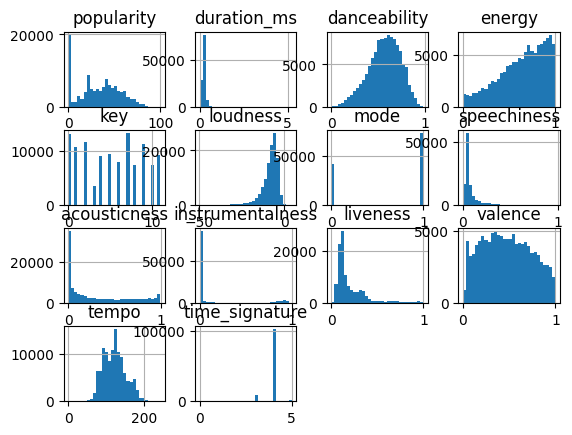

In [4]:
potential_features = spotify.drop(['track_name', 'artists', 'track_id', 'album_name', 'track_genre'], axis=1)

potential_features.hist(bins=30)
plt.show()

Close to normal:
- danceability
- tempo
- popularity (maybe not very useful for my question)
- valence
- duration_ms

Strongly skewed:
- duration_ms
- energy
- instrumentalness
- liveness
- acousticness
- loudness
- speechiness

In [5]:
# box plot
# features_excluding_explicit = potential_features.drop(['explicit'], axis=1)

# for feature in features_excluding_explicit:
#     plt.figure(figsize=(6, 2))
#     plt.boxplot(features_excluding_explicit[feature], vert=False)
#     plt.title(feature)
#     plt.show()

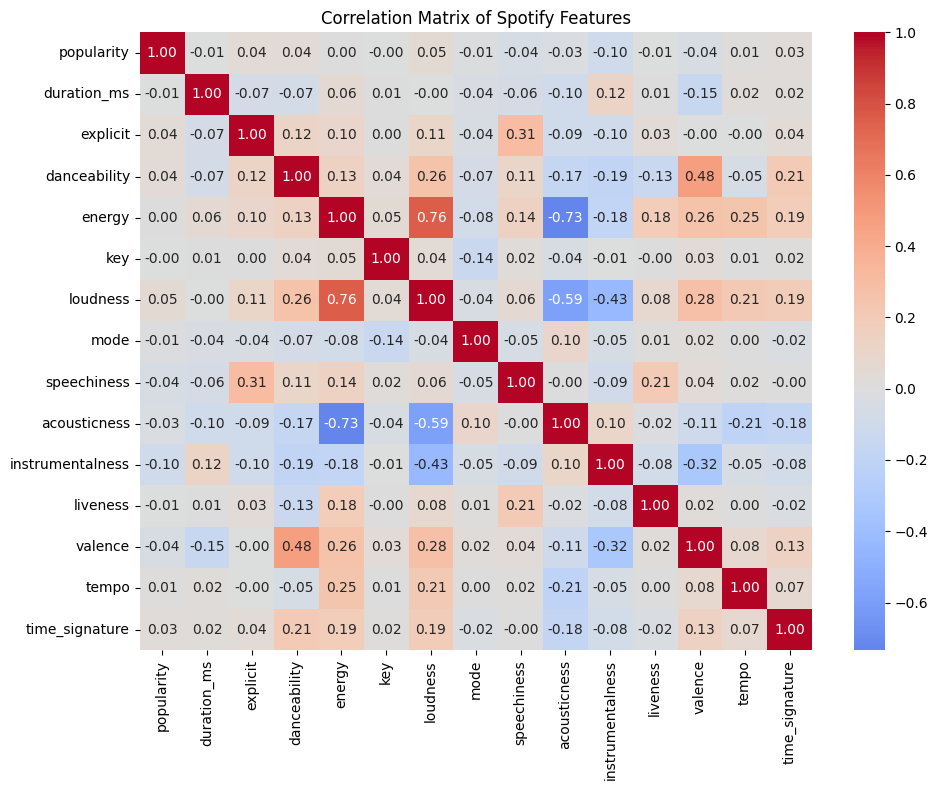

In [6]:
# Checking correlation between features
correlation_matrix = potential_features.corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Correlation Matrix of Spotify Features')
plt.tight_layout()
plt.show()

Assuming thershold of 0.7 and -0.7 as highly correlated, the following factors are of concern:
- loudness vs energy
- acousticness vs energy

In [7]:
# final features
continuous_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

categorical_or_discrete_features = [
    'key',
    'mode',
    'time_signature'
]

In [8]:
# standardization
X = spotify[continuous_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

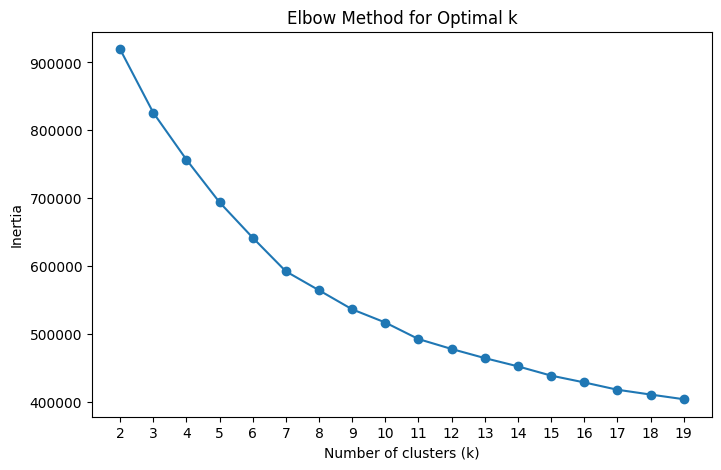

In [9]:
# testing for right amount of clusters

inertia_values = []

k_values= range(2, 20)

for k in k_values:
    kmeans= KMeans(
        n_clusters=k,
        random_state=1,
        n_init=10 #means K-Means tries 10 different starting centroid positions and keeps the best solution.
    )

    kmeans.fit(X_scaled)

    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.show()

No obvious elbow. Using the silhouette score to decide confidently.

In [10]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

k_values = range(2, 13)

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=10000,
        random_state=42
    )
    
    silhouette_scores.append(score)

    print(f"k = {k}: Silhouette Score = {score:.4f}")

k = 2: Silhouette Score = 0.2466
k = 3: Silhouette Score = 0.1582
k = 4: Silhouette Score = 0.1639
k = 5: Silhouette Score = 0.1680
k = 6: Silhouette Score = 0.1688
k = 7: Silhouette Score = 0.1807
k = 8: Silhouette Score = 0.1818
k = 9: Silhouette Score = 0.1641
k = 10: Silhouette Score = 0.1669
k = 11: Silhouette Score = 0.1540
k = 12: Silhouette Score = 0.1549


In [11]:
#Other tests to decide k
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

k_values = list(range(2, 13))

results = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    ch_score = calinski_harabasz_score(X_scaled, labels)
    db_score = davies_bouldin_score(X_scaled, labels)

    results.append((k, ch_score, db_score))

    print(
        f"k={k} | "
        f"Calinski-Harabasz={ch_score:.2f} | "
        f"Davies-Bouldin={db_score:.4f}"
    )

k=2 | Calinski-Harabasz=27345.08 | Davies-Bouldin=1.6517
k=3 | Calinski-Harabasz=21667.46 | Davies-Bouldin=1.9947
k=4 | Calinski-Harabasz=19239.22 | Davies-Bouldin=1.7993
k=5 | Calinski-Harabasz=18324.47 | Davies-Bouldin=1.7029
k=6 | Calinski-Harabasz=17703.22 | Davies-Bouldin=1.6092
k=7 | Calinski-Harabasz=17578.99 | Davies-Bouldin=1.4660
k=8 | Calinski-Harabasz=16623.12 | Davies-Bouldin=1.3267
k=9 | Calinski-Harabasz=16048.71 | Davies-Bouldin=1.3646
k=10 | Calinski-Harabasz=15620.66 | Davies-Bouldin=1.3569
k=11 | Calinski-Harabasz=14996.04 | Davies-Bouldin=1.4244
k=12 | Calinski-Harabasz=14385.48 | Davies-Bouldin=1.4656


2 clusters is too small. Doing cluster stability and interpretability comparion for k= 6, 7 and 8.

In [15]:
# stability test with ARI
from sklearn.metrics import adjusted_rand_score
import numpy as np

def cluster_stability(X, k, seeds=range(10)):
    label_sets = []

    for seed in seeds:
        model = KMeans(
            n_clusters=k,
            random_state=seed,
            n_init=10
        )
        
        labels = model.fit_predict(X)
        label_sets.append(labels)

    ari_scores = []

    for i in range(len(label_sets)):
        for j in range(i + 1, len(label_sets)):
            ari = adjusted_rand_score(
                label_sets[i],
                label_sets[j]
            )
            ari_scores.append(ari)

    return np.mean(ari_scores), np.std(ari_scores)

mean_ari_6, std_ari_6 = cluster_stability(X_scaled, 6)
mean_ari_7, std_ari_7 = cluster_stability(X_scaled, 7)
mean_ari_8, std_ari_8 = cluster_stability(X_scaled, 8)

print("k=6:", mean_ari_6, std_ari_6)
print("k=7:", mean_ari_7, std_ari_7)
print("k=8:", mean_ari_8, std_ari_8)

k=6: 0.9958717297858093 0.001563312211150086
k=7: 0.9940024900965703 0.0025550932939413483
k=8: 0.8054381878064141 0.13928267061329264


## ARI

The **Adjusted Rand Index** measures how similar two different clustering results are.

It compares whether *pairs of observations are grouped together or separated in the same way across two clusterings*.

ARI is useful when we want to compare two sets of cluster labels.

**Typical use cases**:
- checking whether clustering results are stable across different random seeds
- comparing two clustering algorithms
- comparing clustering results before and after changing features
- comparing predicted clusters with known labels, if external labels exist

**Interpreting the scores**:
- 1  perfectly stable
- more than 0.90   very stable
- 0.75–0.90 strong stability
- 0.50–0.75 moderate stability
- less than 0.50   weak stability
- 0 perfectly instable

**Limitation**:
So ARI answers:
>“Are the clusters reproducible?”

not:
>“Are these the best possible clusters?”

In [16]:
# For practice also doing centroid profiling

#Fitting KMeans models
kmeans_6 = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

labels_6 = kmeans_6.fit_predict(X_scaled)

kmeans_7 = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

labels_7 = kmeans_7.fit_predict(X_scaled)

In [20]:
#Getting the centroids
centroids_6_original = scaler.inverse_transform(
    kmeans_6.cluster_centers_
)

centroids_7_original = scaler.inverse_transform(
    kmeans_7.cluster_centers_
)


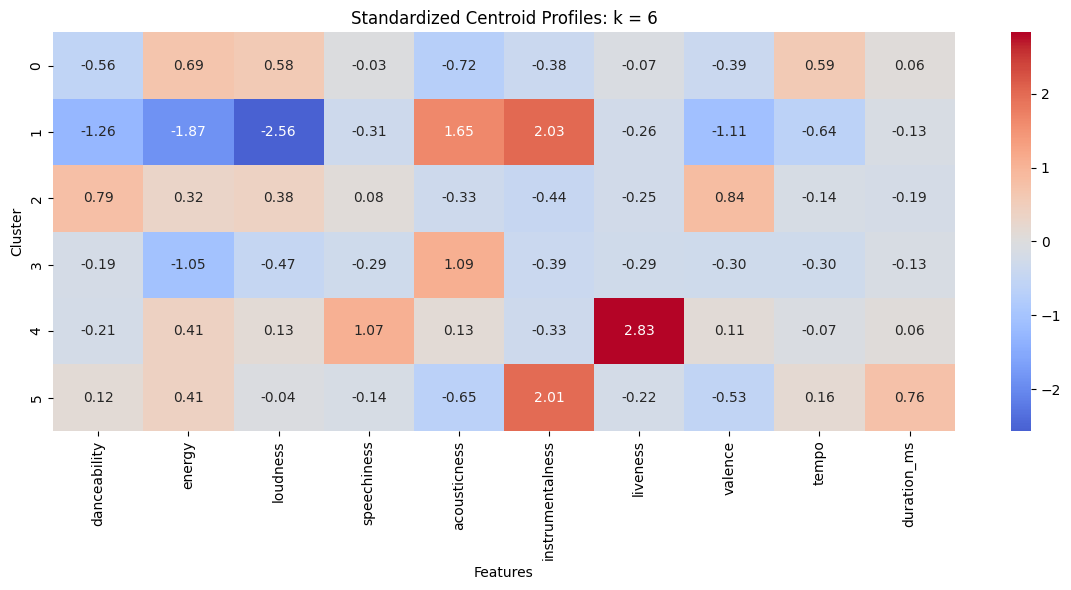

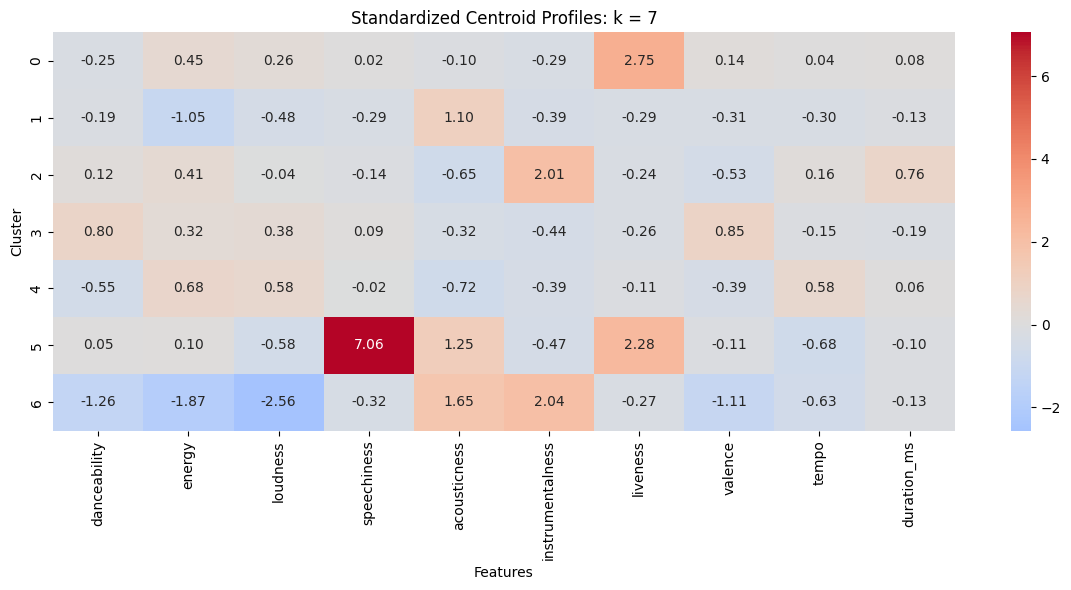

In [21]:
profiles_6_scaled = pd.DataFrame(
    kmeans_6.cluster_centers_,
    columns=continuous_features
)

profiles_7_scaled = pd.DataFrame(
    kmeans_7.cluster_centers_,
    columns=continuous_features
)

profiles_6_scaled.index.name = 'cluster'
profiles_7_scaled.index.name = 'cluster'


plt.figure(figsize=(12, 6))

sns.heatmap(
    profiles_6_scaled,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Standardized Centroid Profiles: k = 6')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

sns.heatmap(
    profiles_7_scaled,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Standardized Centroid Profiles: k = 7')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [22]:
#Checking number of songs in extra cluster
cluster_sizes_7 = pd.Series(labels_7).value_counts().sort_index()

print(cluster_sizes_7)

print("\nPercentages:")
print(cluster_sizes_7 / len(labels_7) * 100)

0     7777
1    23071
2    11454
3    36519
4    26652
5     1107
6     7420
Name: count, dtype: int64

Percentages:
0     6.821930
1    20.237719
2    10.047368
3    32.034211
4    23.378947
5     0.971053
6     6.508772
Name: count, dtype: float64


## Question 1

Seven clusters were selected as the final K-Means solution because it provided the best balance between cluster quality, stability, and interpretability. 

Although the silhouette score was slightly higher for \(k=8\), the \(k=8\) solution was substantially less stable across repeated runs, with a mean Adjusted Rand Index (ARI) of 0.805 and a relatively high standard deviation. 

In contrast, \(k=7\) produced an extremely stable solution, with a mean ARI of approximately 0.994 and very low variability. The \(k=7\) solution also achieved a better silhouette score and Davies–Bouldin score than \(k=6\), while maintaining clearly differentiated centroid profiles. Therefore, \(k=7\) was chosen as the most robust and interpretable clustering solution.

speechiness         7.377656
loudness            3.141362
liveness            3.042101
energy              2.556484
instrumentalness    2.513493
acousticness        2.371932
danceability        2.054099
valence             1.951341
tempo               1.261830
duration_ms         0.952774
dtype: float64


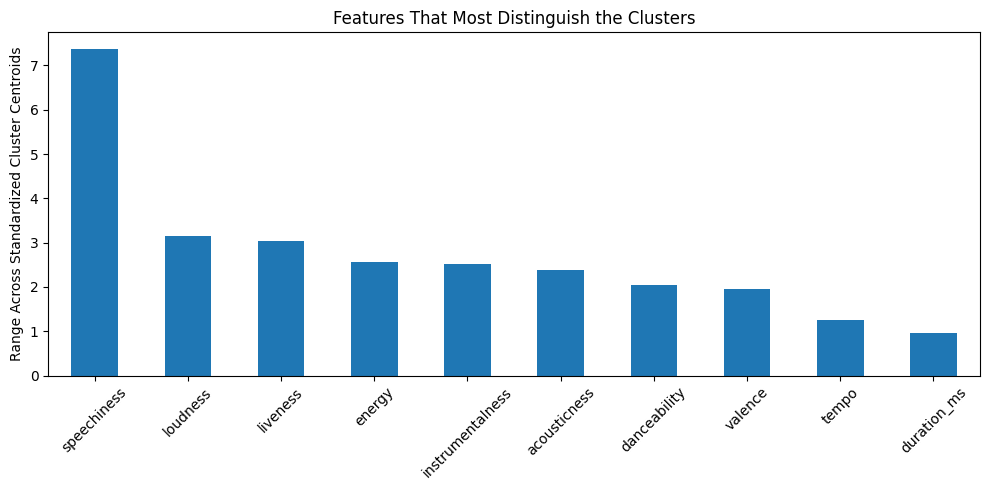

In [23]:
# Which audio features most strongly distinguish the clusters?

feature_separation = (
    profiles_7_scaled.max() - profiles_7_scaled.min()
).sort_values(ascending=False)

print(feature_separation)

feature_separation.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.ylabel('Range Across Standardized Cluster Centroids')
plt.title('Features That Most Distinguish the Clusters')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Question 2

**Speechiness was the strongest feature distinguishing the clusters**, with a standardized centroid range of 7.38. This indicates that at least one cluster differs very substantially from the others in terms of spoken-word content. 

Loudness (3.14) and liveness (3.04) were the next most differentiating features, followed by energy (2.56), instrumentalness (2.51), and acousticness (2.37). Danceability (2.05) and valence (1.95) also contributed meaningfully to cluster differentiation, while tempo (1.26) and duration (0.95) showed comparatively smaller differences across clusters. 

Overall, the clusters appear to be distinguished primarily by **speech content, intensity/loudness, live-performance characteristics, and the balance between instrumental and acoustic qualities**, rather than by track duration or tempo alone.

In [24]:
# Naming the clusters based on their profiles
for cluster in profiles_7_scaled.index:

    print(f"\nCluster {cluster}")

    print(
        profiles_7_scaled
        .loc[cluster]
        .sort_values(ascending=False)
    )


Cluster 0
liveness            2.748902
energy              0.450950
loudness            0.255454
valence             0.144937
duration_ms         0.080088
tempo               0.043147
speechiness         0.022150
acousticness       -0.102016
danceability       -0.253747
instrumentalness   -0.286333
Name: 0, dtype: float64

Cluster 1
acousticness        1.103266
duration_ms        -0.131281
danceability       -0.194340
liveness           -0.293199
speechiness        -0.293862
tempo              -0.301239
valence            -0.306191
instrumentalness   -0.387192
loudness           -0.475646
energy             -1.054735
Name: 1, dtype: float64

Cluster 2
instrumentalness    2.006409
duration_ms         0.763022
energy              0.406946
tempo               0.161087
danceability        0.118477
loudness           -0.039595
speechiness        -0.137710
liveness           -0.239216
valence            -0.533615
acousticness       -0.646866
Name: 2, dtype: float64

Cluster 3
valence       

In [27]:
#Adding cluster names
spotify_clustered = spotify.copy()

spotify_clustered['cluster'] = labels_7

cluster_names = {
    0: 'Live & Energetic',
    1: 'Acoustic & Mellow',
    2: 'Instrumental & Extended',
    3: 'Danceable & Upbeat',
    4: 'Fast & Intense',
    5: 'Speech-Heavy & Live',
    6: 'Ambient Instrumental'
}

spotify_clustered['cluster_name'] = (
    spotify_clustered['cluster']
    .map(cluster_names)
)

spotify_clustered[
    ['track_name', 'artists', 'cluster', 'cluster_name']
].head()

,track_name,artists,cluster,cluster_name
0,Comedy,Gen Hoshino,3,Danceable & Upbeat
1,Ghost - Acoustic,Ben Woodward,1,Acoustic & Mellow
2,To Begin Again,Ingrid Michaelson;ZAYN,1,Acoustic & Mellow
3,Can't Help Falling In Love,Kina Grannis,1,Acoustic & Mellow
4,Hold On,Chord Overstreet,1,Acoustic & Mellow


## Question 3

Based on the characteristics, the clusters were named with the help of ChatGPT.

In [30]:
#Comparing with the given genres

genre_cluster_pct = pd.crosstab(
    spotify_clustered['track_genre'],
    spotify_clustered['cluster_name'],
    normalize='index'
) * 100

#Finding dominant cluster for each genre and the percentage of songs in that cluster
dominant_cluster = genre_cluster_pct.idxmax(axis=1)

dominant_percentage = genre_cluster_pct.max(axis=1)

genre_summary = pd.DataFrame({
    'dominant_cluster': dominant_cluster,
    'percentage_in_dominant_cluster': dominant_percentage
})

genre_summary.sort_values(
    'percentage_in_dominant_cluster',
    ascending=False
)



,dominant_cluster,percentage_in_dominant_cluster
track_genre,,
reggaeton,Danceable & Upbeat,87.9
minimal-techno,Instrumental & Extended,87.9
latino,Danceable & Upbeat,87.3
reggae,Danceable & Upbeat,85.2
dancehall,Danceable & Upbeat,84.9
...,...,...
psych-rock,Danceable & Upbeat,33.3
british,Acoustic & Mellow,33.0
electronic,Danceable & Upbeat,32.8


### Normalized Mutual Information

Normalized Mutual Information measures **how much information two different labelings share**.

In clustering, it is commonly used to compare:
- the clusters found by an unsupervised algorithm
- with some known external labels, such as class or genre labels

**Interpretation**:
|           NMI | Meaning                          |
| ------------: | -------------------------------- |
|           `0` | no meaningful shared information |
|  close to `0` | weak relationship                |
| middle values | partial relationship             |
|  close to `1` | strong correspondence            |
|           `1` | perfect agreement                |


In [31]:
# Performing NMI to confirm results

from sklearn.metrics import normalized_mutual_info_score
nmi_score = normalized_mutual_info_score(
    spotify_clustered['track_genre'],
    spotify_clustered['cluster']
)

print("NMI score:", nmi_score)


NMI score: 0.16732221753680884


## Question 4

The Normalized Mutual Information score between the audio-based clusters and Spotify genre labels was 0.167, indicating weak overall correspondence. This suggests that the seven clusters do not reproduce Spotify’s genre taxonomy directly. However, the genre-level analysis showed that several individual genres were strongly concentrated within specific clusters. 

Therefore, the **clusters appear to capture broader sonic characteristics shared across multiple genres** rather than one-to-one genre categories.

In [32]:
#PCA to check if less features can be used
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


print(pca.explained_variance_ratio_)
print("Total variance explained:",
      pca.explained_variance_ratio_.sum())

[0.28738924 0.15239652]
Total variance explained: 0.4397857615654085


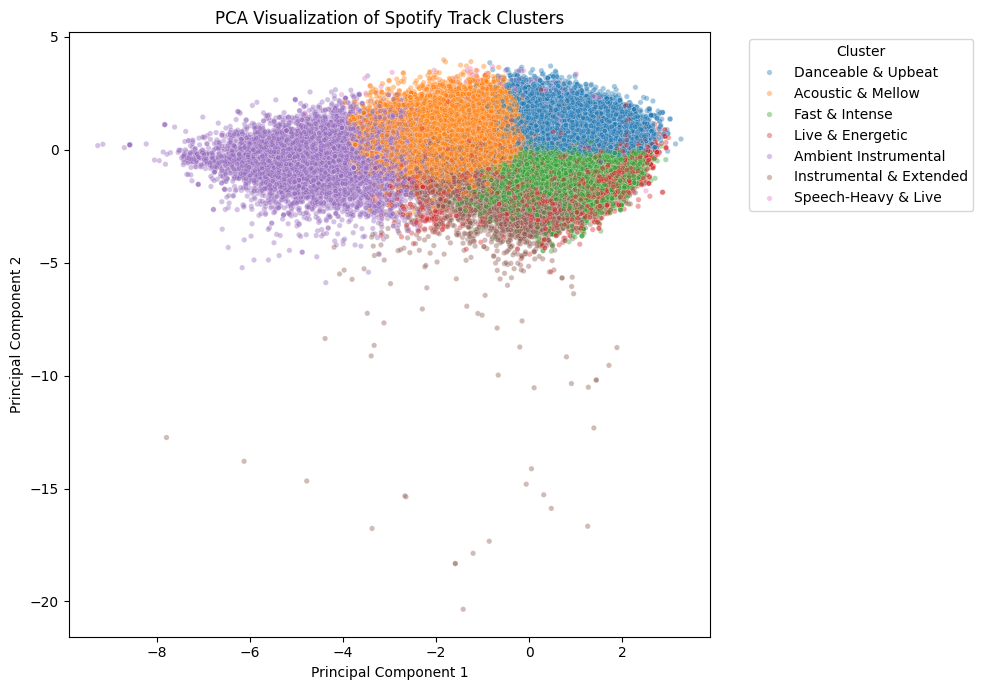

In [33]:
# Visualizing PCA

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['cluster'] = labels_7
pca_df['cluster_name'] = pca_df['cluster'].map(cluster_names)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster_name',
    alpha=0.4,
    s=15
)

plt.title('PCA Visualization of Spotify Track Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(
    title='Cluster',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

## Question 5

The first two principal components explained approximately 44% of the total variance in the standardized audio features, with PC1 accounting for 28.7% and PC2 for 15.2%. Therefore, the two-dimensional PCA representation captures a meaningful but incomplete portion of the original feature space.

Thus, PCA reveals recognizable regions associated with several clusters, while also showing substantial overlap, suggesting that Spotify tracks form overlapping sonic profiles rather than perfectly separated musical categories.